# 0. Que analisis realizaremos

# <small>1.</small> Importacion de librerias

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# <small>1.1</small> importacion de dataset

In [4]:
df = pd.read_csv('../Data/VentaHipermercado.csv')

# <small>2.</small> IDA

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [6]:
df['Product Name'].nunique()

1849

In [7]:
df[['Order Date','Ship Date']].head(2)

,Order Date,Ship Date
0,08/11/2017,11/11/2017
1,08/11/2017,11/11/2017


## <small>2.2</small> Modificacion de dato de str a datetime 

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y',errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y',errors='coerce')

In [9]:
df[['Ship Date','Order Date']].isna().sum()

Ship Date     0
Order Date    0
dtype: int64

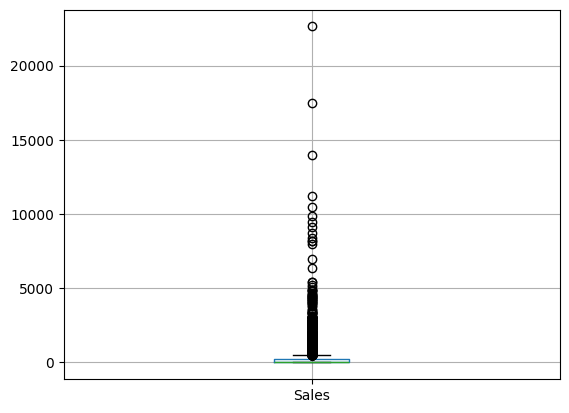

In [10]:
df.boxplot(column='Sales')
plt.show()

In [11]:
df['Sales'].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

# <small>3.</small> EDA

## <small>3.1 </small> Analisis de ventas

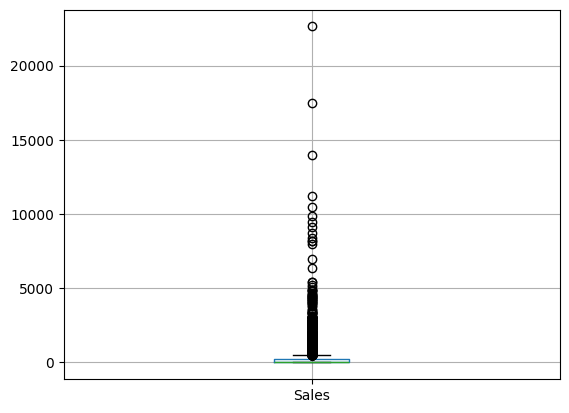

In [12]:
df.boxplot(column='Sales')
plt.show()

En este grafico podemos ver que tenemos muchos outlier en esta columna, por lo que tendremos que analizar a que se deben y que hacer con ellos.

In [13]:
df['Sales'].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

In [14]:
df['Sales'].quantile([0.90, 0.95, 0.99, 0.999])

0.900     575.932000
0.950     959.984000
0.990    2480.207800
0.999    8230.327526
Name: Sales, dtype: float64

Los cuantiles muestran un crecimiento acelerado en los percentiles altos, lo que indica una distribucion fuertemente cesgada a la derecha. Esto sugiera la presencia de una cola larga donde un pequeno porcentaje de observaciones concentran valores significativamente mayores al resto

In [15]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

(df['Sales'] > limite_superior).sum()

np.int64(1145)

In [16]:
(df['Sales'] > limite_superior).mean()

np.float64(0.11683673469387755)

Estos outliers o valores altos que encontramos en los percentiles, son el ~11.6% de los datos que se encuentran en esta columna

In [17]:
df['Sales'].sort_values(ascending=False).head(10)

2697    22638.480
6826    17499.950
8153    13999.960
2623    11199.968
4190    10499.970
9039     9892.740
4098     9449.950
4277     9099.930
8488     8749.950
6425     8399.976
Name: Sales, dtype: float64

In [18]:
(df['Sales'] <= 1).sum()

np.int64(8)

In [19]:
df['Sales_log'] = np.log1p(df['Sales'])

Generaremos una columna de ventas pero en logaritmo, para que cuando mas adelante queramos realizar un modelo con esta columna, esta sea mas estable. Debido a que sube de manera exponencial los valores, el modelo tendra dificultades y con esto podremos realizar solucionar este problema.

In [20]:
df['Sales_log'].describe()

count    9800.000000
mean        4.157532
std         1.592070
min         0.367417
25%         2.904055
50%         4.016203
75%         5.354721
max        10.027451
Name: Sales_log, dtype: float64

## <small>3.2 </small> Analisis fechas de ordenes de compra

In [21]:
meses_por_año = df.groupby(df['Order Date'].dt.year)['Order Date'].apply(lambda x: sorted(x.dt.month.unique()))

print(meses_por_año)

Order Date
2015    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
2016    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
2017    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
2018    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Name: Order Date, dtype: object


In [22]:
df.groupby([df['Order Date'].dt.year, df['Order Date'].dt.month])['Order Date'].apply(lambda x: x.dt.day.nunique())



Order Date  Order Date
2015        1             21
            2             20
            3             24
            4             23
            5             28
            6             25
            7             24
            8             24
            9             28
            10            29
            11            28
            12            28
2016        1             18
            2             17
            3             26
            4             24
            5             27
            6             22
            7             24
            8             22
            9             25
            10            26
            11            28
            12            29
2017        1             21
            2             23
            3             28
            4             26
            5             29
            6             26
            7             25
            8             28
            9             28
            10      

Se observa que la cantidad de días por mes varía significativamente entre periodos, lo que implica diferencias en la exposición temporal de las ventas. Esto puede introducir sesgos en el análisis si se comparan valores agregados mensuales sin normalizar, afectando la interpretación y el rendimiento de modelos de forecasting.

In [23]:
df['Order Date'].min(), df['Order Date'].max()

(Timestamp('2015-01-03 00:00:00'), Timestamp('2018-12-30 00:00:00'))

In [24]:
df['Ship Date'].min(), df['Ship Date'].max()

(Timestamp('2015-01-07 00:00:00'), Timestamp('2019-01-05 00:00:00'))

In [25]:
df['Order Date'].max() - df['Order Date'].min()

Timedelta('1457 days 00:00:00')

In [26]:
df['Order Date'].nunique()


1230

Existen aproximadamente 227 días dentro del rango temporal que no tienen registros, lo que indica que la serie no es continua.

### <small>3.2.1</small> Verificacion de dias faltantes

In [27]:
rango_completo = pd.date_range(
    start=df['Order Date'].min(),
    end=df['Order Date'].max(),
    freq='D'
)


In [28]:
fechas_existentes = df['Order Date'].drop_duplicates()

In [29]:
fechas_faltantes = (rango_completo.difference(fechas_existentes))
dfFechas = fechas_faltantes.to_frame(index=False , name='Fechas')
dfFechas

,Fechas
0,2015-01-08
1,2015-01-12
2,2015-01-17
3,2015-01-21
4,2015-01-22
...,...
223,2018-09-27
224,2018-10-11
225,2018-10-18
226,2018-10-25


In [30]:
dfFechas.groupby([dfFechas['Fechas'].dt.year, dfFechas['Fechas'].dt.month])['Fechas'].apply(lambda x: x.dt.day.unique())

Fechas  Fechas
2015    1                           [8, 12, 17, 21, 22, 24, 25, 29]
        2                            [5, 9, 10, 13, 19, 25, 26, 28]
        3                                 [6, 8, 9, 12, 13, 20, 27]
        4                                [3, 9, 10, 14, 17, 24, 27]
        5                                               [1, 15, 29]
        6                                       [5, 11, 12, 19, 26]
        7                               [3, 10, 16, 17, 24, 29, 31]
        8                               [7, 10, 13, 14, 18, 21, 28]
        9                                                   [4, 18]
        10                                                 [23, 30]
        11                                                  [6, 13]
        12                                             [11, 18, 25]
2016    1         [1, 7, 8, 11, 14, 15, 16, 18, 20, 21, 22, 25, 29]
        2              [1, 2, 4, 5, 11, 12, 13, 17, 19, 24, 26, 29]
        3                        

Los dias faltantes no presentan un patron temporal sistematico y se distribuyen de manera dispersa a lo largo del tiempo, lo que sugiere que no responde a una logica operativa del negocio,sino que podria ser ausencia de registros o dias sin venta

### <small>3.2.2</small> Verificacion de que sucedio en los dias faltantes

In [31]:
# Ship Date
rangoCEnvio = pd.date_range(
    start=df['Ship Date'].min(),
    end=df['Ship Date'].max(),
    freq='D'
)

In [32]:
fechasEEnvio = df['Ship Date'].drop_duplicates()

In [33]:
fechas_faltantes.isin(fechasEEnvio).sum()

np.int64(195)

Dado que los días faltantes no presentan patrón estructural y existe evidencia de actividad operativa (Se realizaron envios de productos), se imputaran como ventas iguales a cero para mantener la continuidad de la serie temporal


### <small>3.2.3</small> Verificacion estructura de los datos en tiempo

In [34]:
ordersDays = df.groupby([df['Order Date'].dt.year, df['Order Date'].dt.month,df['Order Date'].dt.day])['Order Date'].value_counts().sort_index()
ordersDays

Order Date  Order Date  Order Date  Order Date
2015        1           3           2015-01-03     1
                        4           2015-01-04     3
                        5           2015-01-05     1
                        6           2015-01-06     9
                        7           2015-01-07     2
                                                  ..
2018        12          26          2018-12-26     4
                        27          2018-12-27     2
                        28          2018-12-28    19
                        29          2018-12-29    12
                        30          2018-12-30     7
Name: count, Length: 1230, dtype: int64

In [35]:
df[df['Order Date']=="2018-12-28"].groupby('Order ID').value_counts()

Order ID        Row ID  Order Date  Ship Date   Ship Mode       Customer ID  Customer Name       Segment      Country        City           State         Postal Code  Region   Product ID       Category         Sub-Category  Product Name                                                            Sales     Sales_log
CA-2018-101322  6150    2018-12-28  2018-12-31  First Class     JG-15310     Jason Gross         Corporate    United States  Long Beach     California    90805.0      West     FUR-CH-10003968  Furniture        Chairs        Novimex Turbo Task Chair                                                340.7040  5.833945     1
CA-2018-122798  8099    2018-12-28  2019-01-01  Standard Class  SV-20935     Susan Vittorini     Consumer     United States  Albuquerque    New Mexico    87105.0      West     OFF-PA-10004239  Office Supplies  Paper         Xerox 1953                                                              4.2800    1.663926     1
                8098    2018-12-28  2019-0

Se comprueba que los regristros son a nivel de ordenes de compra, debido a esto tenemos duplicidad de registros por dias. Esto deberemos solucionarlo en los pasos previos a la creacion del modelo, para consolidar solo un registro por dia, para entregar solo un dato de venta por dia.

### <small>3.2.4</small> Verificacion de temporalidad

In [36]:
resumen = df.groupby(
    [df['Order Date'].dt.year.rename('year'),
     df['Order Date'].dt.month.rename('month')]
    )['Sales'].sum().reset_index(name='values')


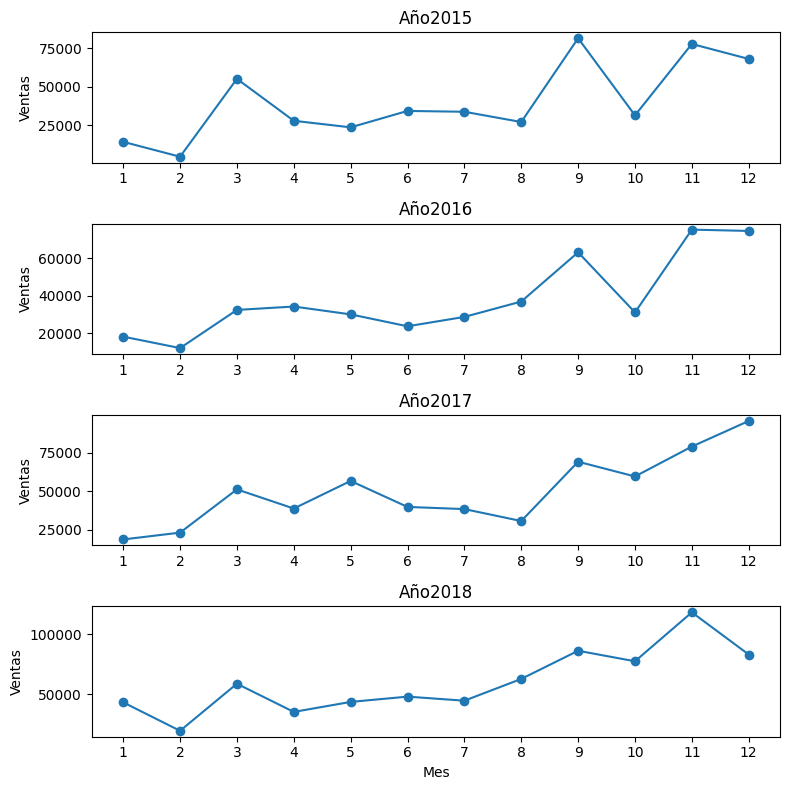

In [37]:
# Creacion del grafico
import matplotlib.pyplot as plt
years = resumen['year'].unique()

fig, axes = plt.subplots(len(years), 1, figsize=(8, 8))

for i, year in enumerate(years):
    dataYear = resumen[resumen['year']==year]
    axes[i].plot(dataYear['month'],
                 dataYear['values'],
                 marker='o')
    axes[i].set_title(f'Año{year}')
    axes[i].set_ylabel('Ventas')
    axes[i].set_xticks(range(1,13))

plt.xlabel('Mes')
plt.tight_layout()
plt.show()
    

Se observa una tendencia creciente en las ventas a lo largo de los años, junto con una estacionalidad anual marcada. Febrero presenta consistentemente los niveles más bajos de ventas, mientras que septiembre, noviembre y diciembre concentran los valores más altos. Este patrón se repite de forma consistente entre años, lo que sugiere una estacionalidad fuerte y relevante para el modelado de forecasting.

Se puede observar una tendencia clara en las ventas, la cual tiende a incrementar, pero con patrones de estacionalidad marcados.Se visualiza que los meses de febrero son los que poseen menor facturacion y que los meses de septiembre noviembre y diciembre se concentran las mayores ventas a lo largo de los a;os. 

### <small>3.2.5</small> Verificacion de temporalidad semanal

In [38]:
df['day_of_week'] = df['Order Date'].dt.dayofweek
ventas_dow = df.groupby('day_of_week')['Sales'].mean().reset_index(name='sales')

In [39]:
ventas_dow

,day_of_week,sales
0,0,218.952638
1,1,222.623570
2,2,257.029269
3,3,264.028170
4,4,219.972671
5,5,235.667120
6,6,222.931432


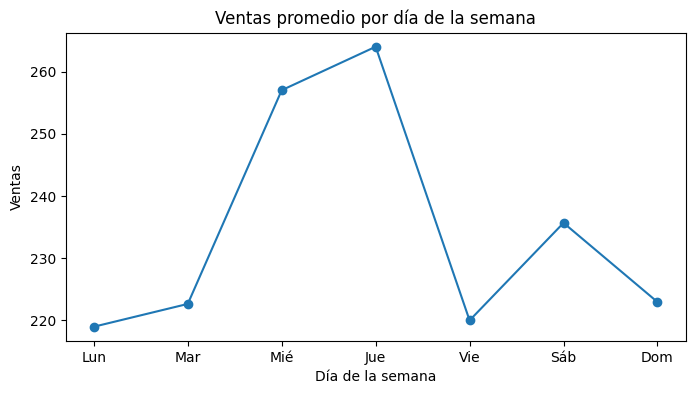

In [40]:
plt.figure(figsize=(8,4))
plt.plot(
    ventas_dow['day_of_week'],
    ventas_dow['sales'],
    marker='o'
)
plt.title('Ventas promedio por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Ventas')
plt.xticks(
    range(7),
    ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
)

plt.show()

In [41]:
# 1. ventas por día
ventas_diarias = df.groupby('Order Date')['Sales'].sum().reset_index()


In [42]:

# 2. día de la semana
ventas_diarias['day_of_week'] = ventas_diarias['Order Date'].dt.dayofweek
# 3. promedio por día de la semana
ventas_dow2 = ventas_diarias.groupby('day_of_week')['Sales'].mean().reset_index(name='sales')


In [43]:
ventas_dow2

,day_of_week,sales
0,0,1788.674624
1,1,2113.245851
2,2,1671.370223
3,3,1170.813444
4,4,1862.784446
5,5,2136.555717
6,6,1870.637514


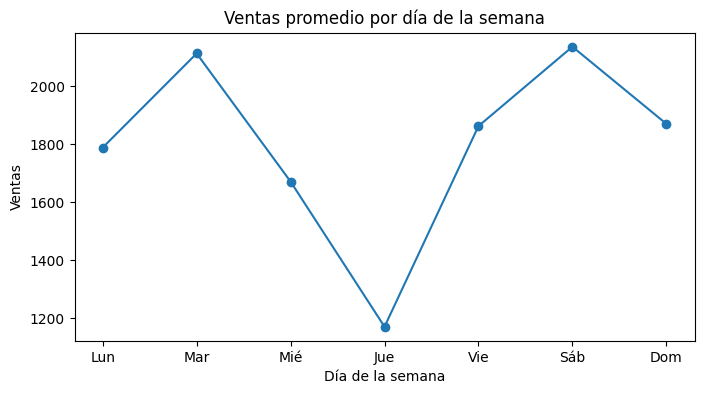

In [44]:
plt.figure(figsize=(8,4))
plt.plot(
    ventas_dow2['day_of_week'],
    ventas_dow2['sales'],
    marker='o'
)
plt.title('Ventas promedio por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Ventas')
plt.xticks(
    range(7),
    ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
)

plt.show()

- Se observa una variación significativa en las ventas promedio por día, con picos en martes y sábado y un mínimo en jueves, lo que sugiere la presencia de una estacionalidad semanal moderada.
- Este junto con los analisis anteriores son realizando una analisis de ventas solamente tomando en cuenta los dias que exiten ventas

### <small>3.2.6</small> Verificacion de temporalidad semanal en promedio por dia calendario

In [45]:
ventas_diarias = df.groupby('Order Date')['Sales'].sum()

Representacion de la cantidad de dias que deberian existir

In [46]:
rango_completo = pd.date_range(
    start=ventas_diarias.index.min(),
    end=ventas_diarias.index.max(),
    freq='D'
)

Agregar los dias faltantes , y estos quedaran como NaN

In [47]:
ventas_diarias = ventas_diarias.reindex(rango_completo)

Y ahora rellenaremos con 0 los dias que tienen NaN

In [48]:
ventas_diarias = ventas_diarias.fillna(0)

In [49]:
ventas_diarias = ventas_diarias.reset_index()
ventas_diarias.columns = ['date', 'sales']

In [50]:
ventas_diarias['day_of_week'] = ventas_diarias['date'].dt.dayofweek

In [51]:
ventas_dow3 = ventas_diarias.groupby('day_of_week')['sales'].mean().reset_index(name='sales')

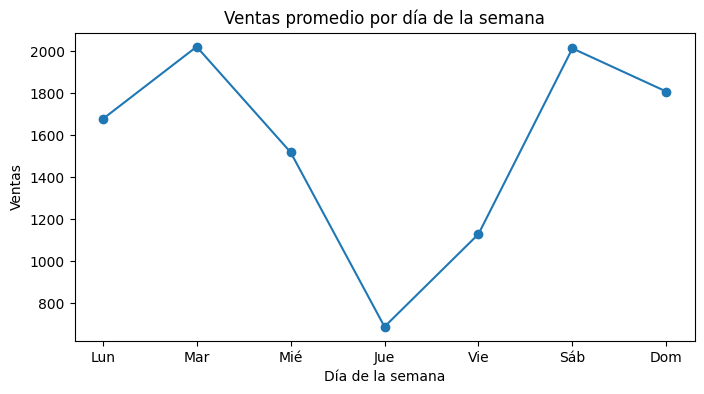

In [52]:
plt.figure(figsize=(8,4))
plt.plot(
    ventas_dow3['day_of_week'],
    ventas_dow3['sales'],
    marker='o'
)
plt.title('Ventas promedio por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Ventas')
plt.xticks(
    range(7),
    ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
)

plt.show()

“Al incorporar los días sin ventas, los valores promedio disminuyen, especialmente en aquellos días con menor volumen, como jueves. Sin embargo, el patrón general se mantiene, con picos en martes y sábado, lo que indica que la estacionalidad semanal es consistente y no un efecto del sesgo en los datos.”

### <small>3.2.7</small> Verificacion de temporalidad semanal por a;o en promedio por dia calendario

In [53]:
ventas_diarias.head(2)

,date,sales,day_of_week
0,2015-01-03,16.448,5
1,2015-01-04,288.060,6


In [54]:
ventas_diarias['year'] = ventas_diarias['date'].dt.year

In [55]:
ventas_diarias.head(1)

,date,sales,day_of_week,year
0,2015-01-03,16.448,5,2015


In [56]:
regSem = ventas_diarias.groupby(['year','day_of_week'])['sales'].mean().reset_index(name='sales')

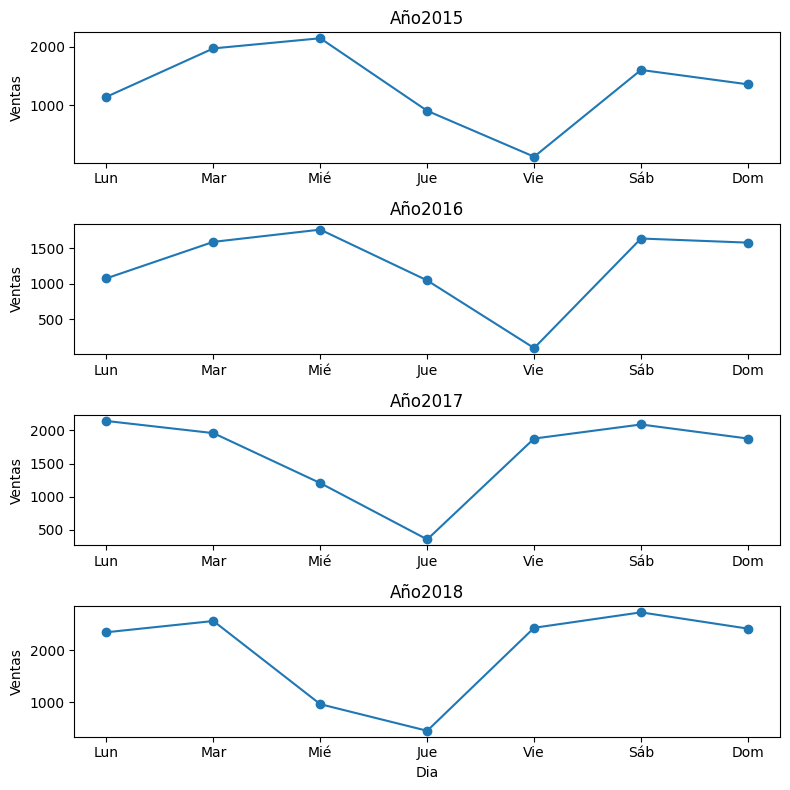

In [57]:
# Creacion del grafico
import matplotlib.pyplot as plt
years = regSem['year'].unique()

fig, axes = plt.subplots(len(years), 1, figsize=(8, 8))

for i, year in enumerate(years):
    dataYear = regSem[regSem['year']==year]
    axes[i].plot(dataYear['day_of_week'],
                 dataYear['sales'],
                 marker='o')
    axes[i].set_title(f'Año{year}')
    axes[i].set_ylabel('Ventas')
    axes[i].set_xticks(
    range(7),
    ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
)

plt.xlabel('Dia')
plt.tight_layout()
plt.show()

    

“Si bien se observa variación en las ventas según el día de la semana, este patrón no es consistente entre años, lo que sugiere que la estacionalidad semanal es inestable y posiblemente influenciada por cambios en el comportamiento del negocio.

# <small>4.</small> Implementacion de ARIMA

## <small>4.1</small> Preparacion de los datos

In [58]:
newResumen = df.groupby(
    [df['Order Date'].dt.year.rename('year'),
     df['Order Date'].dt.month.rename('month')]
    )['Sales_log'].sum().reset_index(name='values')



In [59]:
resumen['day'] = 1

Preparacion de la columna 'date' para poder utilizar con arima

In [60]:
resumen["date"]=pd.to_datetime(resumen[['year','month','day']])
resumen = resumen.sort_values('date')
resumen.set_index('date',inplace=True)
resumen.drop(columns=['day'],inplace=True)
resumen.index.freq = 'MS'

In [61]:
# creacion de la variable 'y'
y = resumen['values']

## <small>4.2</small> Division de entrenamiento y prueba (train/test)

In [62]:
train = y.loc[:'2017-12-01']
test = y.loc['2018-01-01':]

## <small>4.3</small> Entrenar el modelo con auto_arima

In [63]:
# El motor de Auto-ARIMA
import pmdarima as pm

# Métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [64]:
print("Buscando el mejor modelo ARIMA... (esto puede tardar unos segundos)")

# Configurar y entrenar Auto-ARIMA
modelo_arima = pm.auto_arima(
    train, 
    seasonal=True,   # Activamos el componente estacional (SARIMA)
    m=12,            # Ciclo de 12 meses
    stepwise=True,   # Método de búsqueda rápida
    suppress_warnings=True,
    error_action="ignore"
)

# Ver el resultado del modelo encontrado
print(modelo_arima.summary())

Buscando el mejor modelo ARIMA... (esto puede tardar unos segundos)
                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                   36
Model:             SARIMAX(1, 0, 0)x(0, 0, [1, 2], 12)   Log Likelihood                -404.869
Date:                                 Tue, 02 Jun 2026   AIC                            819.738
Time:                                         09:02:32   BIC                            827.656
Sample:                                     01-01-2015   HQIC                           822.501
                                          - 12-01-2017                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
interc

## <small>4.4</small> Generar pronosticos y graficos

============ EVALUACIÓN EN EL CONJUNTO DE PRUEBA (2018) ============
MAE (Error absoluto promedio): 17909.76
MAPE (Porcentaje de error promedio): 30.00%


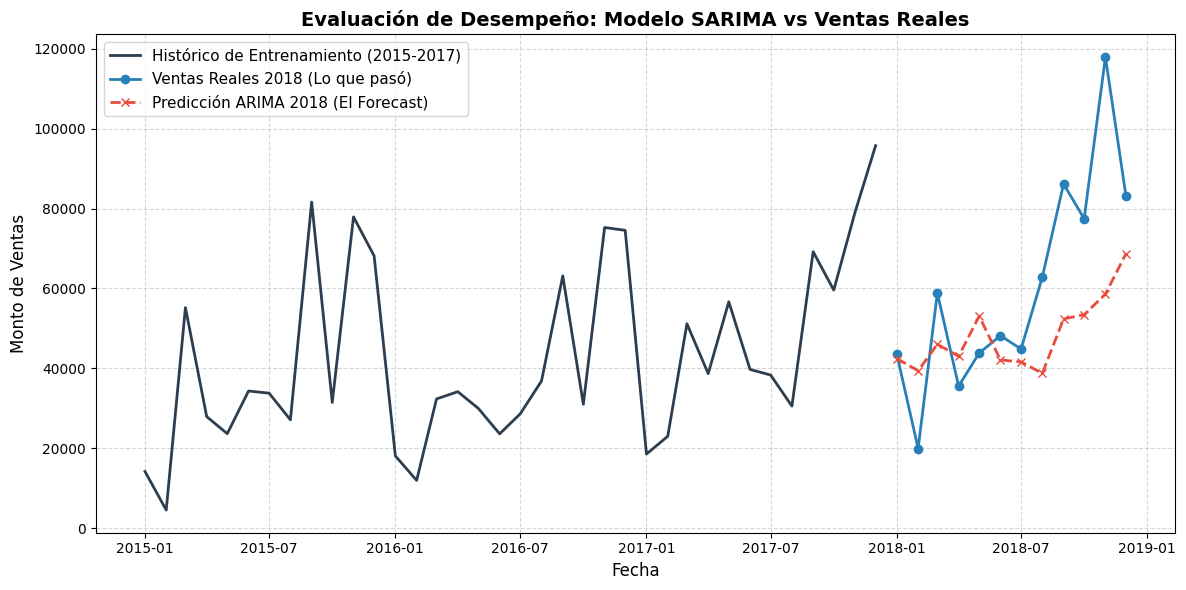

In [65]:
# 1. Predecir los próximos 12 meses (todo el año 2018)
predicciones = modelo_arima.predict(n_periods=12)

# 2. Convertir a una serie de Pandas alineada con las fechas de tu conjunto test
predicciones = pd.Series(predicciones, index=test.index)

# 3. Calcular los errores comparando las ventas reales de 2018 con las predicciones
mae = mean_absolute_error(test, predicciones)
mape = mean_absolute_percentage_error(test, predicciones)

print("============ EVALUACIÓN EN EL CONJUNTO DE PRUEBA (2018) ============")
print(f"MAE (Error absoluto promedio): {mae:.2f}")
print(f"MAPE (Porcentaje de error promedio): {mape * 100:.2f}%")
print("====================================================================")

# 4. Construir el gráfico para presentar a negocio
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Histórico de Entrenamiento (2015-2017)', color='#2c3e50', linewidth=2)
plt.plot(test.index, test, label='Ventas Reales 2018 (Lo que pasó)', color='#2980b9', marker='o', linewidth=2)
plt.plot(predicciones.index, predicciones, label='Predicción ARIMA 2018 (El Forecast)', color='#e74c3c', linestyle='--', marker='x', linewidth=2)

plt.title('Evaluación de Desempeño: Modelo SARIMA vs Ventas Reales', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Monto de Ventas', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# <small>5.</small> Implementacion de ARIMA con ventas en logaritmo

## <small>5.1</small> Preparacion de los datos

In [66]:
dataLog = df.groupby(
    [df['Order Date'].dt.year.rename('year'),
     df['Order Date'].dt.month.rename('month')]
    )['Sales_log'].sum().reset_index(name='values')

In [67]:
dataLog['day'] = 1

Preparacion de la columna 'date' para poder utilizar con arima

In [68]:
dataLog["date"]=pd.to_datetime(dataLog[['year','month','day']])
dataLog = dataLog.sort_values('date')
dataLog.set_index('date',inplace=True)
dataLog.drop(columns=['day'],inplace=True)
dataLog.index.freq = 'MS'

In [69]:
y_log = np.log(dataLog['values'])
y_real = dataLog['values']

## <small>5.2</small> Division de entrenamiento y prueba (train/test)

In [70]:
train_log = y_log.loc[:'2017-12-01']
test_real = y_real.loc['2018-01-01':]

## <small>5.3</small> Entrenar el modelo con auto_arima

In [71]:
print("Entrenando ARIMA con datos logarítmicos...")
modelo_arima_log = pm.auto_arima(
    train_log, 
    seasonal=True,   
    m=12,            
    stepwise=True,   
    suppress_warnings=True,
    error_action="ignore"
)

Entrenando ARIMA con datos logarítmicos...


## <small>5.4</small> Generar pronosticos y graficos


============ NUEVA EVALUACIÓN (CON TRUCO LOGARÍTMICO) ============
NUEVO MAE (Error absoluto promedio): 127.52
NUEVO MAPE (Porcentaje de error promedio): 12.32%


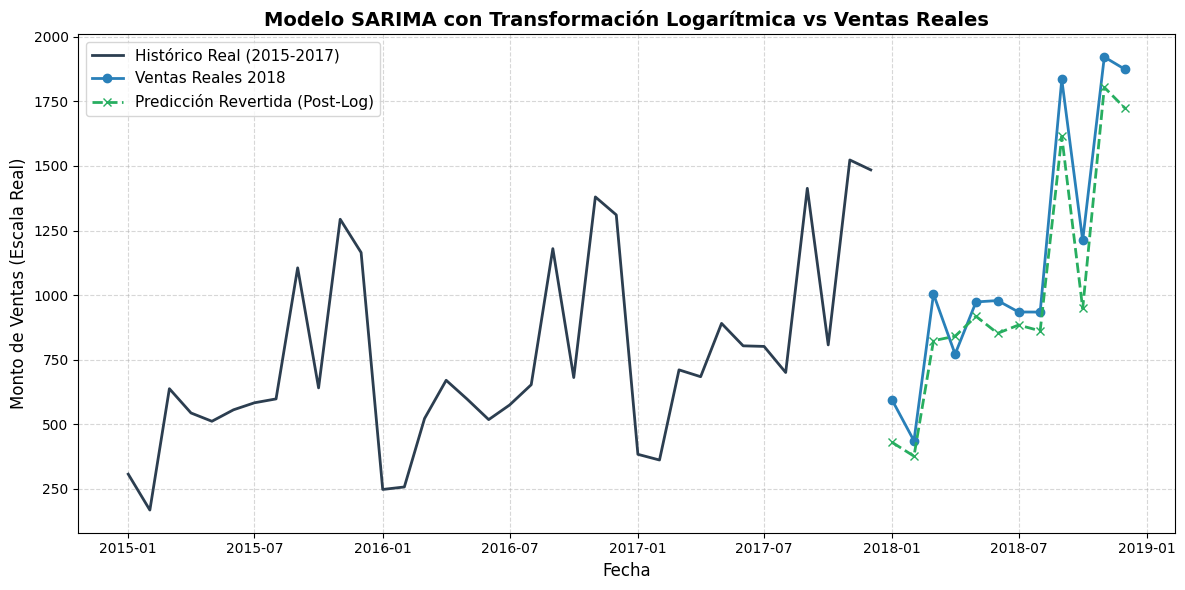

In [72]:
# ==========================================
# 4. PREDICCIÓN Y REVERSIÓN (DESTRANSFORMACIÓN)
# ==========================================
# El modelo nos devolverá predicciones en escala logarítmica
predicciones_log = modelo_arima_log.predict(n_periods=12)

# REVERTIMOS EL LOGARITMO usando la función exponencial para volver a la escala real de dinero
predicciones_reales = np.exp(predicciones_log)
predicciones_reales = pd.Series(predicciones_reales, index=test_real.index)


# ==========================================
# 5. NUEVA EVALUACIÓN DE MÉTRICAS
# ==========================================
mae_nuevo = mean_absolute_error(test_real, predicciones_reales)
mape_nuevo = mean_absolute_percentage_error(test_real, predicciones_reales)

print("\n============ NUEVA EVALUACIÓN (CON TRUCO LOGARÍTMICO) ============")
print(f"NUEVO MAE (Error absoluto promedio): {mae_nuevo:.2f}")
print(f"NUEVO MAPE (Porcentaje de error promedio): {mape_nuevo * 100:.2f}%")
print("====================================================================")

train_real = y_real.loc[:'2017-12-01']

plt.figure(figsize=(12, 6))
plt.plot(train_real.index, train_real, label='Histórico Real (2015-2017)', color='#2c3e50', linewidth=2)
plt.plot(test_real.index, test_real, label='Ventas Reales 2018', color='#2980b9', marker='o', linewidth=2)
plt.plot(predicciones_reales.index, predicciones_reales, label='Predicción Revertida (Post-Log)', color='#27ae60', linestyle='--', marker='x', linewidth=2)

plt.title('Modelo SARIMA con Transformación Logarítmica vs Ventas Reales', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Monto de Ventas (Escala Real)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# <small>6.</small> Implementacion Prophet

## <small>6.1</small> Preparacion de los datos

In [73]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [77]:
dfProphet = df.groupby(
    [df['Order Date'].dt.year.rename('year'),
     df['Order Date'].dt.month.rename('month')]
    )['Sales_log'].sum().reset_index(name='values')

In [78]:
dfProphet['day'] = 1

Preparacion de la columna 'date' para poder utilizar con arima

In [80]:
dfProphet["date"]=pd.to_datetime(dfProphet[['year','month','day']])
dfProphet = dfProphet.sort_values('date')
dfProphet.set_index('date',inplace=True)
dfProphet.drop(columns=['day'],inplace=True)
dfProphet.index.freq = 'MS'

In [81]:
dfProphet.head(2)

,year,month,values
date,,,
2015-01-01,2015,1,307.122341
2015-02-01,2015,2,168.120240


In [ ]:
dfProphet = dfProphet.reset_index() # Por si la fecha estaba en el índice


In [85]:
df_prophet = dfProphet.rename(columns={'date': 'ds', 'values': 'y'})

In [86]:
df_prophet.head(2)

,ds,year,month,y
0,2015-01-01,2015,1,307.122341
1,2015-02-01,2015,2,168.120240


## <small>6.2</small> Division de entrenamiento y prueba (train/test)

In [87]:
train_prophet = df_prophet[df_prophet['ds'] < '2018-01-01']
test_prophet = df_prophet[df_prophet['ds'] >= '2018-01-01']

## <small>6.3</small> Entrenar el modelo

In [96]:
model_prophet = Prophet(
    seasonality_mode='multiplicative', 
    yearly_seasonality=True,  # Forzamos a que aprenda el ciclo anual
    weekly_seasonality=False, # Desactivamos la semanal porque tus datos son mensuales
    daily_seasonality=False
)

model_prophet.fit(train_prophet)

09:57:29 - cmdstanpy - INFO - Chain [1] start processing
09:57:30 - cmdstanpy - INFO - Chain [1] done processing


## <small>6.4</small> Generar pronosticos y graficos

============ EVALUACIÓN PROPHET (TEST 2018) ============
MAE de Prophet: 152.68
MAPE de Prophet: 14.58%


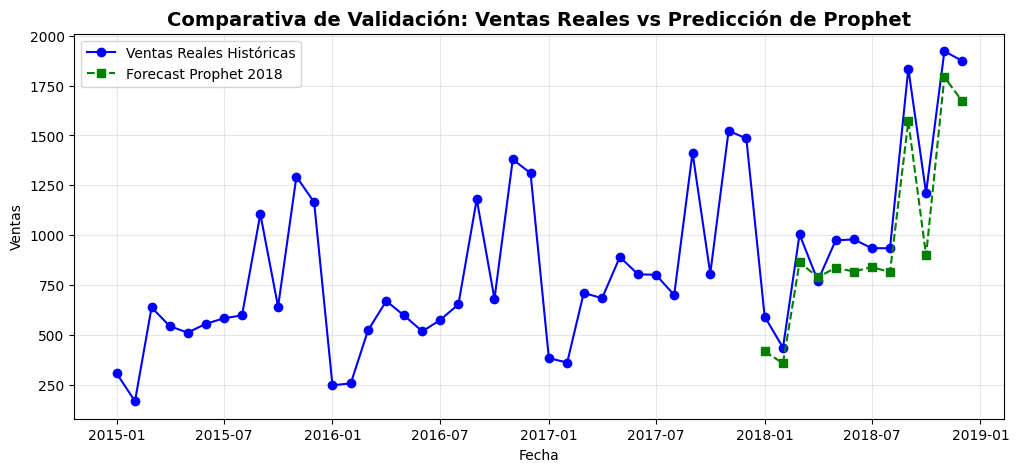

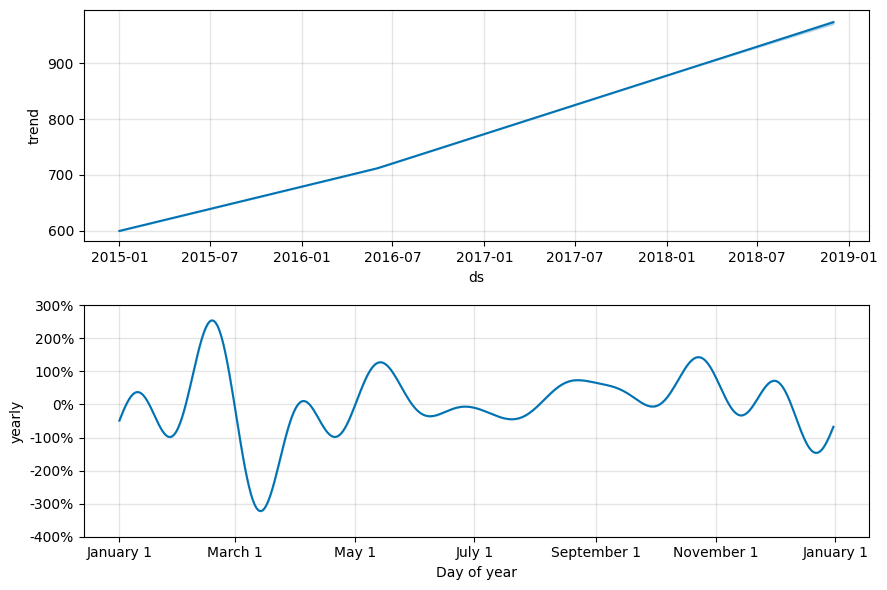

In [97]:
# ==========================================
# PASO 3: FORECAST (PREDICCIÓN)
# ==========================================
# Creamos un dataframe con los meses del futuro para el año 2018
future_dates = model_prophet.make_future_dataframe(periods=12, freq='MS')

# El modelo predice todo el histórico más los 12 meses del futuro
forecast = model_prophet.predict(future_dates)

# Filtraciones para evaluar únicamente el periodo de prueba (2018)
predicciones_2018 = forecast[forecast['ds'] >= '2018-01-01']['yhat'].values
reales_2018 = test_prophet['y'].values

# ==========================================
# PASO 4: EVALUACIÓN DE MÉTRICAS
# ==========================================
mae_prophet = mean_absolute_error(reales_2018, predicciones_2018)
mape_prophet = mean_absolute_percentage_error(reales_2018, predicciones_2018) * 100

print(f"============ EVALUACIÓN PROPHET (TEST 2018) ============")
print(f"MAE de Prophet: {mae_prophet:.2f}")
print(f"MAPE de Prophet: {mape_prophet:.2f}%")
print(f"========================================================")

# ==========================================
# PASO 5: GRAFICAR LA COMPARATIVA
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Ventas Reales Históricas', color='blue', marker='o')
plt.plot(test_prophet['ds'], predicciones_2018, label='Forecast Prophet 2018', color='green', linestyle='--', marker='s')
plt.title('Comparativa de Validación: Ventas Reales vs Predicción de Prophet', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# BONUS MENTOR: Descomponer los componentes del modelo para analizarlos
model_prophet.plot_components(forecast)
plt.show()